## Part A

## Designing and Analyzing Convolutional Neural Networks from Scratch.

### loading dataset

### data understanding and visualization

In [1]:
# import libraries
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

I0000 00:00:1777647507.908096      73 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777647508.292568      73 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777647509.724715      73 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# define the path to the dataset
train_dir = "./dataset/Traffic_Sign_-2/Train/"
test_dir = "./dataset/Traffic_Sign_-2/Test/"

### Check for classnames

In [3]:
# Get class names (subdirectories)
class_names_raw = sorted(os.listdir(train_dir))
print("Raw class names:", class_names_raw)

# Normalize 'DIrection' -> 'Direction'
class_names = []
for name in class_names_raw:
    if name == 'DIrection':
        class_names.append('Direction')
    else:
        class_names.append(name)
class_names = sorted(class_names)
print("Normalized class names:", class_names)

# Create mapping from original folder name to normalized name
folder_to_label = {}
for name in class_names_raw:
    if name == 'DIrection':
        folder_to_label[name] = 'Direction'
    else:
        folder_to_label[name] = name

Raw class names: ['Cautions', 'Crossings', 'DIrection', 'No Entry', 'SpeedLimit']
Normalized class names: ['Cautions', 'Crossings', 'Direction', 'No Entry', 'SpeedLimit']


### check for corrupted images and remove them

In [4]:
from PIL import Image, UnidentifiedImageError
import os

corrupted_images = [] # list to store corrupted images path
 
for class_name in class_names_raw:
    class_path = os.path.join(train_dir, class_name)
    if  os.path.isdir(class_path): # check if it is valid
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

print("Corrupted Images found: ", len(corrupted_images))
for img in corrupted_images[:5]:
    print(img)

# Remove corrupted files
for img_path in corrupted_images:
    try:
        os.remove(img_path)
        print(f"Removed: {img_path}")
    except Exception as e:
        print(f"Error removing {img_path}: {e}")
print("Removal done.")

Corrupted Images found:  0
Removal done.


### get the image sizes

In [5]:
def inspect_image_sizes(folder: str, sample_size: int = 10):
    """Check actual image sizes in the dataset before any resizing."""
    sizes = []
    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name) 
        if not os.path.isdir(class_path): 
            continue
        for filename in os.listdir(class_path): 
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')): 
                continue
            img_path = os.path.join(class_path, filename) 
            img = Image.open(img_path) 
            sizes.append(img.size)  # returns (width, height)
            if len(sizes) >= sample_size: 
                break
        if len(sizes) >= sample_size:
            break

    sizes = np.array(sizes)
    print(f"Sample of sizes (W x H): {sizes}")
    print(f"Min: {sizes.min(axis=0)}, Max: {sizes.max(axis=0)}")
    return sizes

inspect_image_sizes(train_dir)

Sample of sizes (W x H): [[ 53  49]
 [ 47  45]
 [ 40  38]
 [ 45  39]
 [ 46  47]
 [181 165]
 [131 117]
 [ 44  40]
 [ 43  41]
 [ 83  82]]
Min: [40 38], Max: [181 165]


array([[ 53,  49],
       [ 47,  45],
       [ 40,  38],
       [ 45,  39],
       [ 46,  47],
       [181, 165],
       [131, 117],
       [ 44,  40],
       [ 43,  41],
       [ 83,  82]])

### load the images from folder

In [6]:
img_width, img_height = 64, 64

def load_images_from_folder(folder: str, has_labels: bool = True):
    images, labels = [], []

    if has_labels:
        # use normalized class names
        class_list = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])
        # map original folder name to normalized label index
        label_map = {}
        for orig in class_list:
            norm = folder_to_label.get(orig, orig)
            label_map[orig] = class_names.index(norm)
        
        for orig_name in class_list:
            class_path = os.path.join(folder, orig_name)
            label = label_map[orig_name]

            for filename in os.listdir(class_path):
                if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue
                img_path = os.path.join(class_path, filename)
                if img_path in corrupted_images:
                    continue
                try:
                    img = Image.open(img_path).convert("RGB")
                    img = img.resize((img_width, img_height))
                    img = np.array(img, dtype="float32") / 255.0
                    images.append(img)
                    labels.append(label)
                except Exception as e:
                    print(f"Skipping {img_path}: {e}")
    else:
        # flat folder — no labels, just load images
        for filename in sorted(os.listdir(folder)):
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img_path = os.path.join(folder, filename)
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize((img_width, img_height))
                img = np.array(img, dtype="float32") / 255.0
                images.append(img)
                labels.append(-1)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    if len(images) == 0:
        raise ValueError(f"No images loaded from {folder}. Check your path.")

    images = np.array(images)
    labels = np.array(labels)

    print(f"Total  : {len(images)} images")
    print(f"Shape  : {images.shape}")
    return images, labels

print("Loading training data...")
x_train, y_train = load_images_from_folder(train_dir, has_labels=True)

# some provided test folders are unlabeled (flat folder of images).
# if test has class subfolders, we treat it as labeled and can run evaluate().
def _dir_has_subdirs(path: str) -> bool:
    try:
        return any(os.path.isdir(os.path.join(path, d)) for d in os.listdir(path))
    except FileNotFoundError:
        return False

test_has_labels = _dir_has_subdirs(test_dir)
print("\nLoading test data...", "(labeled)" if test_has_labels else "(unlabeled)")
x_test, y_test = load_images_from_folder(test_dir, has_labels=test_has_labels)
if not test_has_labels:
    y_test = None

Loading training data...
Total  : 16065 images
Shape  : (16065, 64, 64, 3)

Loading test data... (unlabeled)
Total  : 10 images
Shape  : (10, 64, 64, 3)


### insights about dataset

In [7]:
print("Dataset: Traffic Sign Recognition")
print("Task: Multi-class image classification of traffic signs")
print(f"Total training images : {len(x_train)}")
print(f"Image shape           : {x_train.shape[1:]}")
print(f"Number of classes     : {len(np.unique(y_train))}")
print(f"Total testing images  : {len(x_test)}")

Dataset: Traffic Sign Recognition
Task: Multi-class image classification of traffic signs
Total training images : 16065
Image shape           : (64, 64, 3)
Number of classes     : 5
Total testing images  : 10


### get class distribution

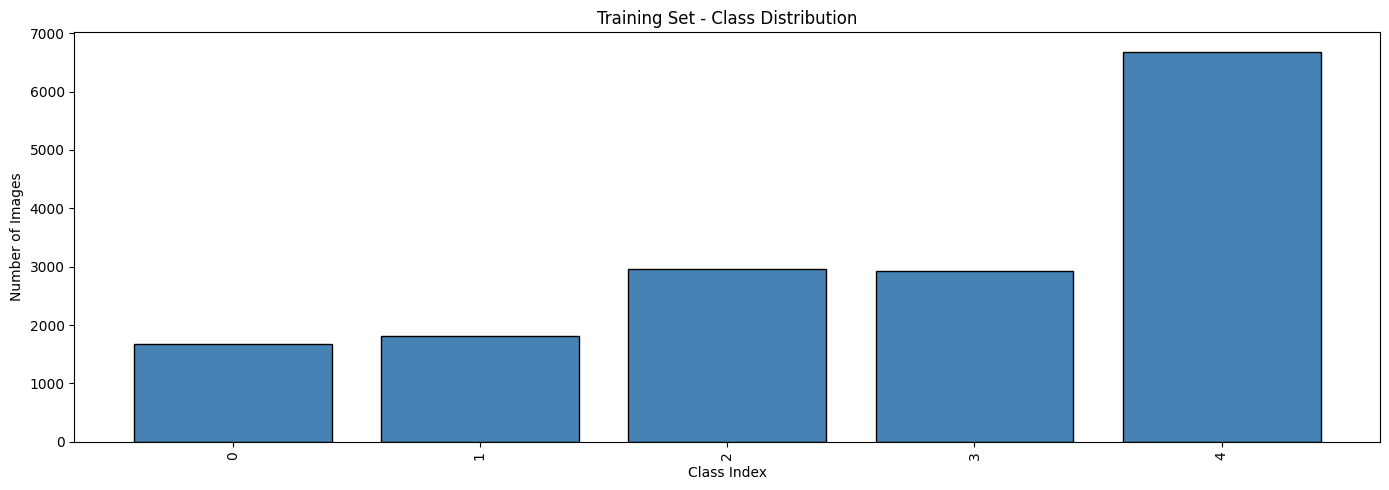

Min images in a class : 1671
Max images in a class : 6681
Mean images per class : 3213.0


In [8]:
def plot_class_distribution(labels, title="Class Distribution"):
    """ Plot the distribution of classes in the dataset."""
    unique, counts = np.unique(labels, return_counts=True)

    # bar plot for class distribution
    plt.figure(figsize=(14, 5))
    plt.bar(unique, counts, color='steelblue', edgecolor='black')
    plt.xlabel("Class Index")
    plt.ylabel("Number of Images")
    plt.title(title)
    plt.xticks(unique, rotation=90)
    plt.tight_layout()
    plt.show()
    print(f"Min images in a class : {counts.min()}")
    print(f"Max images in a class : {counts.max()}")
    print(f"Mean images per class : {counts.mean():.1f}")

plot_class_distribution(y_train, "Training Set - Class Distribution")

### split train into train and validation (stratified)

In [9]:
# stratified split 80/20
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)
print(f"Train split: {x_train_split.shape}, Val split: {x_val_split.shape}")

# compute class weights for imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

Train split: (12852, 64, 64, 3), Val split: (3213, 64, 64, 3)
Class weights: {0: 1.9228007181328546, 1: 1.7644151565074135, 2: 1.0851063829787233, 3: 1.0962128966223132, 4: 0.48091603053435117}


### Data Augmentation

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name="data_augmentation")

I0000 00:00:1777647532.701405      73 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4137 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


### building a Sequential Baseline Model

In [11]:
num_classes = 5
input_shape = (img_width, img_height, 3)

baseline_model = keras.Sequential([
    layers.Input(shape=input_shape),
    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax'),
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 581,381 (2.22 MB)

 Trainable params: 581,381 (2.22 MB)

 Non-trainable params: 0 (0.00 B)

### baseline model compilation 

In [12]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### baseline model training

In [13]:
os.makedirs('./model_checkpoints', exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath='./model_checkpoints/baseline_epoch_{epoch}.keras'),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4)
]

history_baseline = baseline_model.fit(
    x_train_split, y_train_split,
    epochs=250,
    validation_data=(x_val_split, y_val_split),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/250


I0000 00:00:1777647544.736952     168 cuda_dnn.cc:461] Loaded cuDNN version 92101


402/402 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1748 - loss: 1.6685 - val_accuracy: 0.4799 - val_loss: 1.5705
Epoch 2/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2578 - loss: 1.6099 - val_accuracy: 0.1080 - val_loss: 1.6106
Epoch 3/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1646 - loss: 1.6195 - val_accuracy: 0.4158 - val_loss: 1.6052
Epoch 4/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1871 - loss: 1.6097 - val_accuracy: 0.4317 - val_loss: 1.6042
Epoch 5/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2371 - loss: 1.6179 - val_accuracy: 0.4251 - val_loss: 1.6065


### building a Regularized CNN (with BatchNorm and Dropout)

In [15]:
regularized_model = keras.Sequential([
    layers.Input(shape=input_shape),
    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

regularized_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 582,021 (2.22 MB)

 Trainable params: 581,701 (2.22 MB)

 Non-trainable params: 320 (1.25 KB)

In [16]:
callbacks_reg = [
    keras.callbacks.ModelCheckpoint(filepath='./model_checkpoints/regularized_epoch_{epoch}.keras'),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4)
]

history_reg = regularized_model.fit(
    x_train_split, y_train_split,
    epochs=250,
    validation_data=(x_val_split, y_val_split),
    class_weight=class_weight_dict,
    callbacks=callbacks_reg,
    verbose=1
)

Epoch 1/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - accuracy: 0.1859 - loss: 1.6744 - val_accuracy: 0.1040 - val_loss: 1.6108
Epoch 2/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.1785 - loss: 1.6096 - val_accuracy: 0.1827 - val_loss: 1.6100
Epoch 3/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 36s 89ms/step - accuracy: 0.1650 - loss: 1.6096 - val_accuracy: 0.1133 - val_loss: 1.6104
Epoch 4/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 36s 89ms/step - accuracy: 0.1275 - loss: 1.6097 - val_accuracy: 0.1133 - val_loss: 1.6099
Epoch 5/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.1705 - loss: 1.6096 - val_accuracy: 0.4158 - val_loss: 1.6084
Epoch 6/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.1615 - loss: 1.6096 - val_accuracy: 0.1843 - val_loss: 1.6088
Epoch 7/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.1580 - loss: 1.6096 - val_accuracy: 0.1843 - val_loss: 1.6102
Epoch 8/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.1881 - loss: 1

### building Transfer Learning Model (MobileNetV2)

In [17]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=input_shape, include_top=False, weights='imagenet'
)
base_model.trainable = False

# Note: our loader already normalizes to [0, 1], so do NOT rescale again here.
transfer_model = keras.Sequential([
    layers.Input(shape=input_shape),

    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/tmp/ipykernel_954/4277033780.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [18]:
callbacks_transfer = [
    keras.callbacks.ModelCheckpoint(filepath='./model_checkpoints/transfer_epoch_{epoch}.keras'),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4)
]

history_transfer = transfer_model.fit(
    x_train_split, y_train_split,
    epochs=250,
    validation_data=(x_val_split, y_val_split),
    class_weight=class_weight_dict,
    callbacks=callbacks_transfer,
    verbose=1
)

Epoch 1/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.6890 - loss: 0.9165 - val_accuracy: 0.8864 - val_loss: 0.3460
Epoch 2/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.8577 - loss: 0.4638 - val_accuracy: 0.9166 - val_loss: 0.2405
Epoch 3/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9016 - loss: 0.3385 - val_accuracy: 0.9350 - val_loss: 0.1908
Epoch 4/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9179 - loss: 0.2873 - val_accuracy: 0.9446 - val_loss: 0.1635
Epoch 5/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.9352 - loss: 0.2389 - val_accuracy: 0.9502 - val_loss: 0.1474
Epoch 6/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.9441 - loss: 0.2073 - val_accuracy: 0.9546 - val_loss: 0.1333
Epoch 7/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.9535 - loss: 0.1807 - val_accuracy: 0.9608 - val_loss: 0.1186
Epoch 8/250
402/402 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.9609 - loss: 0

## Model Evaluation on Test Set

In [19]:
models = [
    ('Baseline', baseline_model),
    ('Regularized', regularized_model),
    ('Transfer', transfer_model)
]

if y_test is None:
    print("Test set is unlabeled (flat folder). Skipping loss/accuracy evaluation.")
    for name, model in models:
        probs = model.predict(x_test, verbose=0)
        preds = np.argmax(probs, axis=1)
        print(f"{name} - predicted class indices: {preds.tolist()}")
        # If you want class names, map via: class_names[pred]
else:
    for name, model in models:
        loss, acc = model.evaluate(x_test, y_test, verbose=0)
        print(f"{name} - Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

Test set is unlabeled (flat folder). Skipping loss/accuracy evaluation.
Baseline - predicted class indices: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Regularized - predicted class indices: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Transfer - predicted class indices: [4, 4, 3, 3, 0, 0, 1, 1, 2, 2]


## Save and Load the Model

In [21]:
baseline_model.save('baseline_cnn.keras')
regularized_model.save('regularized_cnn.keras')
transfer_model.save('transfer_cnn.keras')

print('Models saved.')

# Example load
# loaded = tf.keras.models.load_model('baseline_cnn.h5')

Models saved.
